In [1]:
!pip install torch

Mounted at /content/drive


In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim


def load_hdf5_mat_file(file_path):
    """
    Load a .mat file and extract hyperspectral image and ground truth data.

    Args:
        file_path (str): Path to the .mat file.

    Returns:
        np.ndarray, np.ndarray: HSI and GT data.
    """
    try:
        data = h5py.File(file_path, 'r')
        hsi_data = np.array(data['HSI'])  # Hyperspectral image data
        gt_data = np.array(data['GT'])   # Ground truth data
        print(f"Loaded file: {file_path}")
        print(f"HSI shape: {hsi_data.shape}, GT shape: {gt_data.shape}")
        return hsi_data, gt_data
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None, None



In [3]:
import os

In [8]:
def ScaleData(X,min_value,max_value):
  #This function scales the data 'X' between 0 and 1
  min_value=np.float16(min_value)
  max_value=np.float16(max_value)
  X -= min_value
  X /= (max_value - min_value)
  return X

In [9]:
from einops import rearrange

def extract_overlapping_patches(image, patch_size, stride):
    """
    Extract overlapping patches from an image.

    Args:
        image (torch.Tensor): Input image of shape [C, H, W].
        patch_size (int): Size of each patch (height and width).
        stride (int): Stride for extracting patches (controls overlap).

    Returns:
        patches (torch.Tensor): Extracted patches of shape [num_patches, C, patch_size, patch_size].
    """
    image = torch.tensor(image)
    # Unfold the image into patches
    if len(image.shape)>2:
        patches = image.unfold(1, patch_size, stride).unfold(2, patch_size, stride)

        # Reshape to [num_patches, C, patch_size, patch_size]
        patches = rearrange(patches,"c h w p1 p2 -> (h w) c p1 p2")
        # patches = patches.contiguous().view(-1, image.size(0), patch_size, patch_size)
    else:

        patches = image.unfold(0, patch_size, stride).unfold(1, patch_size, stride)

        # Reshape to [num_patches, C, patch_size, patch_size]
        patches = rearrange(patches," h w p1 p2 -> (h w) p1 p2")
        # patches = patches.contiguous().view(-1, patch_size, patch_size)

    return patches.numpy()

In [10]:
def split_into_tiles(hsi_data, gt_data, tile_size=32, overlapping=False):
    """
    Split HSI and GT data into smaller tiles of size (tile_size x tile_size).

    Args:
        hsi_data (np.ndarray): Hyperspectral image data.
        gt_data (np.ndarray): Ground truth data.
        tile_size (int): Size of the tiles (default: 32x32).

    Returns:
        list, list: HSI tiles and corresponding GT tiles.
    """
    hsi_tiles = []
    gt_tiles = []

    # scale hsi data between 0 and 1
    hsi_data = ScaleData(hsi_data, np.min(hsi_data), np.max(hsi_data))

    gt_data[gt_data == 0] = 255
    gt_data[gt_data != 255] -= 1

    # pad data to allow all image data to be included
    h = hsi_data.shape[1]
    w = hsi_data.shape[2]
    pad_h = tile_size * (h//tile_size + 1) - h  # Padding needed for height
    pad_w = tile_size * (w//tile_size + 1) - w  # Padding needed for width

    hsi_data = np.pad(hsi_data, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
    gt_data = np.pad(gt_data, ((0, pad_h), (0, pad_w)), mode='constant',constant_values=255)

    if overlapping == True:
      stride=16
      hsi_tiles = extract_overlapping_patches(hsi_data, tile_size, stride)
      gt_tiles = extract_overlapping_patches(gt_data, tile_size, stride)

      filt=np.sum(gt_tiles<100,axis=(1,2))
      a = filt>((tile_size**2)*0.3) # filter data to include only patches with >30% labelled (non-background) data

      hsi_tiles = hsi_tiles[a]
      gt_tiles = gt_tiles[a]

    else:
      rows, cols = gt_data.shape
      for i in range(0, rows, tile_size):
          for j in range(0, cols, tile_size):
              hsi_tile = hsi_data[:, i:i + tile_size, j:j + tile_size]
              gt_tile = gt_data[i:i + tile_size, j:j + tile_size]

              # Check if the tile matches the expected size
              if hsi_tile.shape[1:] == (tile_size, tile_size) and gt_tile.shape == (tile_size, tile_size) and np.any(gt_tile != 255):
                  hsi_tiles.append(hsi_tile)
                  gt_tiles.append(gt_tile)

    return hsi_tiles, gt_tiles


In [11]:
def process_multiple_hsi_files(folder_path, tile_size=32):
    """
    Process multiple .mat files in a folder to create a combined dataset.

    Args:
        folder_path (str): Path to the folder containing .mat files.
        tile_size (int): Size of the tiles (default: 32x32).

    Returns:
        np.ndarray, np.ndarray: Combined HSI tiles and GT tiles.
    """
    combined_hsi_tiles = []
    combined_gt_tiles = []

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.mat'):
            file_path = os.path.join(folder_path, file_name)

            # Load the file
            hsi_data, gt_data = load_hdf5_mat_file(file_path)
            if hsi_data is None or gt_data is None:
                continue

            # Split into tiles
            hsi_tiles, gt_tiles = split_into_tiles(hsi_data, gt_data, tile_size, overlapping=True)
            combined_hsi_tiles.extend(hsi_tiles)
            combined_gt_tiles.extend(gt_tiles)

    # Convert to NumPy arrays
    combined_hsi_tiles = np.array(combined_hsi_tiles)
    combined_gt_tiles = np.array(combined_gt_tiles)

    print(f"Total number of HSI tiles: {len(combined_hsi_tiles)}")
    print(f"Total number of GT tiles: {len(combined_gt_tiles)}")

    return combined_hsi_tiles, combined_gt_tiles

In [8]:
folder_path = r"C:\Users\ChloeAtherton\Capstone\data"  # Path to the folder containing .mat files
tile_size = 32

# Process all files in the folder
hsi_tiles, gt_tiles = process_multiple_hsi_files(folder_path, tile_size)

# Verify the combined dataset
print(f"Final dataset shape - HSI tiles: {hsi_tiles.shape}, GT tiles: {gt_tiles.shape}")

Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC12.mat
HSI shape: (270, 2884, 682), GT shape: (2884, 682)
Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC13.mat
HSI shape: (270, 808, 1098), GT shape: (808, 1098)
Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC16.mat
HSI shape: (270, 976, 1060), GT shape: (976, 1060)
Total number of HSI tiles: 4388
Total number of GT tiles: 4388
Final dataset shape - HSI tiles: (4388, 270, 32, 32), GT tiles: (4388, 32, 32)


In [9]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test)
hsi_train, hsi_test, gt_train, gt_test = train_test_split(
    hsi_tiles, gt_tiles, test_size=0.2, random_state=42
)

print(f"Train set: {len(hsi_train)} samples")
print(f"Test set: {len(hsi_test)} samples")


Train set: 3510 samples
Test set: 878 samples


In [10]:
import torch
import torch.nn as nn

class ResUNet(nn.Module):
    def __init__(self, in_channels=270, num_classes=14):
        super(ResUNet, self).__init__()
        self.num_classes = num_classes

        # Residual block
        def res_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        # Encoder with residual blocks
        self.enc1 = res_block(in_channels, 64)
        self.enc2 = res_block(64, 128)
        self.enc3 = res_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        # 1x1 convolution for residual matching in encoders
        self.res1 = nn.Conv2d(in_channels, 64, kernel_size=1, bias=False)
        self.res2 = nn.Conv2d(64, 128, kernel_size=1, bias=False)
        self.res3 = nn.Conv2d(128, 256, kernel_size=1, bias=False)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = res_block(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = res_block(128, 64)
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder with residual connections
        enc1 = self.enc1(x) + self.res1(x)  # Residual connection on input
        enc2 = self.enc2(self.pool(enc1)) + self.res2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2)) + self.res3(self.pool(enc2))

        # Decoder
        dec3 = self.dec3(torch.cat([self.up3(enc3), enc2], dim=1))
        dec2 = self.dec2(torch.cat([self.up2(dec3), enc1], dim=1))

        return self.final(dec2)


In [11]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import random

class HyperspectralDataset(Dataset):
    def __init__(self, images, masks, hflip=None, vflip=None):
        self.images = images  # Hyperspectral tiles of shape (270, 32, 32)
        self.masks = masks    # Ground truth tiles of shape (32, 32)
        self.hflip = hflip
        self.vflip = vflip

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)  # (270, 32, 32)
        mask = torch.tensor(self.masks[idx], dtype=torch.long)      # (32, 32)
        if self.hflip:
            if random.random() < 0.5:
                image = v2.functional.horizontal_flip(image)
                mask = v2.functional.horizontal_flip(mask)
        if self.vflip:
            if random.random() < 0.5:
                image = v2.functional.vertical_flip(image)
                mask = v2.functional.vertical_flip(mask)
        return image, mask

# Split into training and testing
train_dataset = HyperspectralDataset(hsi_train, gt_train)
test_dataset = HyperspectralDataset(hsi_test, gt_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [12]:
import torch
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

unique_classes = torch.unique(torch.tensor(gt_tiles))
print(f"Unique classes in masks: {unique_classes}")
print(f"Number of classes: {len(unique_classes)}")

for images, masks in train_loader:
    print(f"Input shape: {images.shape}")
    print(f"Ground truth shape: {masks.shape}")
    break

import torch
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available.")


Is CUDA available: True
PyTorch version: 2.6.0+cu126
Using device: cuda
Unique classes in masks: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15, 255], dtype=torch.uint8)
Number of classes: 17
Input shape: torch.Size([32, 270, 32, 32])
Ground truth shape: torch.Size([32, 32, 32])
CUDA device: NVIDIA RTX 2000 Ada Generation Laptop GPU


Using device: cuda
Model is on device: cuda:0
Epoch 1/70, Training Loss: 1.1222, Validation Loss: 0.7353
Epoch 2/70, Training Loss: 0.7429, Validation Loss: 1.7578
Epoch 3/70, Training Loss: 0.6410, Validation Loss: 0.5212
Epoch 4/70, Training Loss: 0.5204, Validation Loss: 0.5440
Epoch 5/70, Training Loss: 0.5112, Validation Loss: 0.5281
Epoch 6/70, Training Loss: 0.4526, Validation Loss: 0.6329
Epoch 7/70, Training Loss: 0.4094, Validation Loss: 0.4056
Epoch 8/70, Training Loss: 0.3847, Validation Loss: 0.9640
Epoch 9/70, Training Loss: 0.4017, Validation Loss: 0.3426
Epoch 10/70, Training Loss: 0.3692, Validation Loss: 0.4126
Epoch 11/70, Training Loss: 0.3569, Validation Loss: 0.4268
Epoch 12/70, Training Loss: 0.3503, Validation Loss: 0.2535
Epoch 13/70, Training Loss: 0.3209, Validation Loss: 0.5536
Epoch 14/70, Training Loss: 0.3029, Validation Loss: 0.7215
Epoch 15/70, Training Loss: 0.2817, Validation Loss: 0.3452
Epoch 16/70, Training Loss: 0.3238, Validation Loss: 0.6148
Epo

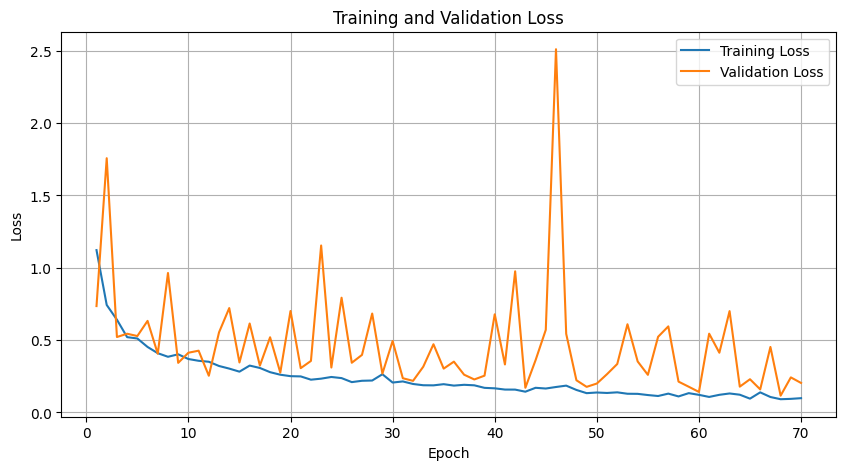

Model weights saved to: C:\Users\ChloeAtherton\Capstone\models\weights_resunet_test.pth


In [20]:
# TRAINING SCRIPT

import matplotlib.pyplot as plt
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to the correct device
model = ResUNet(in_channels=270, num_classes=17).to(device)
print(f"Model is on device: {next(model.parameters()).device}")

save_file = r"C:\Users\ChloeAtherton\Capstone\models\weights_resunet_test.pth"
plot_file = r"C:\Users\ChloeAtherton\Capstone\models\resnet_plot.jpg"

# Ensure criterion is defined
criterion = nn.CrossEntropyLoss(ignore_index = 255)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, save_file, plot_file, num_epochs=10):
    model.train()  # Set the model to training mode

    # Store losses for plotting
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        model.train()  # Set the model to training mode

        # Training loop
        for images, masks in train_loader:
            # Check the model's output shape

            # Move data to the appropriate device
            images, masks = images.to(device), masks.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)  # Output: (batch_size, num_classes, H, W)

            # Compute loss
            loss = criterion(outputs, masks)
            running_train_loss += loss.item()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

        # Calculate average training loss for this epoch
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation loop
        running_val_loss = 0.0
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():

            for images, masks in test_loader:
                # Move data to the appropriate device
                images, masks = images.to(device), masks.to(device)

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, masks)
                running_val_loss += loss.item()

        # Calculate average validation loss for this epoch
        avg_val_loss = running_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Plot the losses
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid()
      # Save the plot before showing it
    if plot_file is not None:
        plot_dir = os.path.dirname(plot_file)
        if plot_dir and not os.path.exists(plot_dir):
            os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(plot_file)
        print(f"Plot saved to: {plot_file}")

    # Show the plot after saving
    plt.show()

    # Save the model checkpoint if a path is provided
    if save_file is not None:
        save_dir = os.path.dirname(save_file)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        torch.save(model.state_dict(), save_file)
        print(f"Model weights saved to: {save_file}")
    

     # Return losses so they can be unpacked by the caller
    return train_losses, val_losses




train_losses, val_losses = train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, save_file, plot_file, num_epochs=70)
   



In [1]:
def evaluate_model(model, dataloader, criterion):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_pixels = 0
    iou_scores = []
    dice_scores = []

    with torch.no_grad():  # Disable gradient computation
        for images, masks in dataloader:
            # Move data to the appropriate device
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)  # (batch_size, num_classes, height, width)
            preds = torch.argmax(outputs, dim=1)  # Predicted class for each pixel

            # Compute loss
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            # Ignore pixels with 255 as GT
            mask_no_background = masks != 255
            predictions = preds[mask_no_background]
            targets = masks[mask_no_background]

            # Compute pixel-wise accuracy
            total_correct += (predictions == targets).sum().item()
            total_pixels += targets.numel()

            for cls in range(model.num_classes):
                # Calculate intersection and union for the class
                intersection = ((predictions == cls) & (targets == cls)).sum().item()
                union = ((predictions == cls) | (targets == cls)).sum().item()
                dice_denominator = (predictions == cls).sum().item() + (targets == cls).sum().item()
                if union == 0:
                    iou_scores.append(float('nan'))  # No samples for this class
                    dice_scores.append(float('nan'))
                else:
                    iou_scores.append(intersection / union)
                    dice_scores.append(2 * intersection / dice_denominator)

    # Compute average metrics
    print('Total Pixels', total_pixels)
    pixel_accuracy = total_correct / total_pixels

    valid_ious = [iou for iou in iou_scores if not torch.isnan(torch.tensor(iou))]
    mean_iou = sum(valid_ious) / len(valid_ious) if valid_ious else float('nan')

    valid_dice = [dice for dice in dice_scores if not torch.isnan(torch.tensor(dice))]
    mean_dice = sum(valid_dice) / len(valid_dice) if valid_dice else float('nan')

    print(f"Validation Loss: {total_loss / len(dataloader):.4f}")
    print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Dice Score: {mean_dice:.4f}")

    return pixel_accuracy, mean_iou, mean_dice


In [24]:
# Evaluate the model on the test set
import torch
save_file = r"C:\Users\ChloeAtherton\Capstone\models\weights_resunet_test.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResUNet(in_channels=270, num_classes=17).to(device)
model.load_state_dict(torch.load(save_file))
criterion = nn.CrossEntropyLoss(ignore_index=255)
pixel_accuracy, mean_iou, mean_dice = evaluate_model(model, test_loader, criterion)


Total Pixels 620740
Validation Loss: 0.2037
Pixel Accuracy: 0.9355
Mean IoU: 0.7775
Mean Dice Score: 0.8203


In [25]:
class SingleImageDataset(Dataset):
    def __init__(self, image, mask):
        self.image = torch.tensor(image, dtype=torch.float32)  # (270, H, W)
        self.mask = torch.tensor(mask, dtype=torch.long)       # (H, W)

    def __len__(self):
        return 1  # Only one sample

    def __getitem__(self, idx):
        return self.image, self.mask

In [29]:
# try and run the model on a whole dataset?
# try running one file

save_file = r"C:\Users\ChloeAtherton\Capstone\models\weights_resunet_test.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResUNet(in_channels=270, num_classes=17).to(device)
model.load_state_dict(torch.load(save_file))
criterion = nn.CrossEntropyLoss(ignore_index=255)

file_path = r"C:\Users\ChloeAtherton\Capstone\data\NC12.mat"
hsi_data_one, gt_data_one = load_hdf5_mat_file(file_path)

hsi_data_one = ScaleData(hsi_data_one, np.min(hsi_data_one), np.max(hsi_data_one))

gt_data_one[gt_data_one == 0] = 255
gt_data_one[gt_data_one != 255] -= 1

# pad data to allow all image data to be included
multiple_required = 8
h = hsi_data_one.shape[1]
w = hsi_data_one.shape[2]
pad_h = multiple_required * (h//multiple_required + 1) - h  # Padding needed for height
pad_w = multiple_required * (w//multiple_required + 1) - w  # Padding needed for width

hsi_data_one = np.pad(hsi_data_one, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
gt_data_one = np.pad(gt_data_one, ((0, pad_h), (0, pad_w)), mode='constant',constant_values=255)

from torch.utils.data import TensorDataset

# Example image tensor

data = SingleImageDataset(hsi_data_one, gt_data_one)
loader = DataLoader(data, batch_size=1, shuffle=False)

pixel_accuracy_one, mean_iou_one, mean_dice_one = evaluate_model(model, loader, criterion)



Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC12.mat
HSI shape: (270, 2884, 682), GT shape: (2884, 682)
Total Pixels 451746
Validation Loss: 0.1500
Pixel Accuracy: 0.9672
Mean IoU: 0.5665
Mean Dice Score: 0.6141


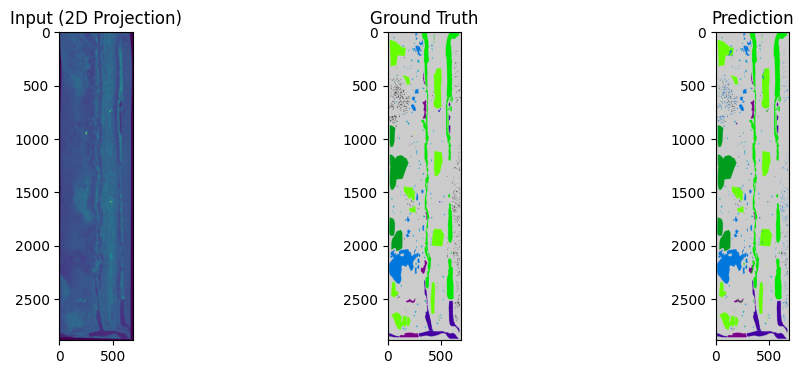

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

def visualize_predictions_2d(model, dataloader):
    model.eval()
    for images, masks in dataloader:
      #images, masks = next(iter(dataloader))  # Get a single batch
      images, masks = images.to(device), masks.to(device)

      with torch.no_grad():
          outputs = model(images)
          preds = torch.argmax(outputs, dim=1)

      # set areas of prediction that is meant to be the background class as such:
      preds[masks == 255] = 255

      # Display predictions
      for i in range(min(10, len(images))):  # Show up to 4 examples

          plt.figure(figsize=(12, 4))

          # Collapse hyperspectral input to 2D by averaging across bands
          # R, G, B = 140, 54, 24
          # images = images.cpu()
          # rgb_patch = np.transpose(np.stack([images[i, R,:,:], images[i, G,:,:], images[i, B,:,:]]), (1, 2, 0))  # (32, 32, 3)
          # # Normalize for better visualization (optional)
          # rgb_patch = (rgb_patch - rgb_patch.min()) / (rgb_patch.max() - rgb_patch.min())

          input_2d = images[i].mean(dim=0).cpu()  # Mean across channels

          plt.subplot(1, 3, 1)
          plt.title("Input (2D Projection)")
          plt.imshow(input_2d)  # Projected to 2D

          # plt.title("Input (RGB Projection)")
          # plt.imshow(rgb_patch)  # Projected to 2D

          plt.subplot(1, 3, 2)
          plt.title("Ground Truth")
          plt.imshow(masks[i].cpu(), cmap='nipy_spectral', vmin=0, vmax=16)

          plt.subplot(1, 3, 3)
          plt.title("Prediction")
          plt.imshow(preds[i].cpu(), cmap='nipy_spectral', vmin=0, vmax=16)

          plt.show()

# Visualize predictions
visualize_predictions_2d(model, loader)


In [12]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
 # Ensure this is accessible from your resunet.py

# Parameters (adjust these paths as needed)
folder_path = r"C:\Users\ChloeAtherton\Capstone\data"  # Folder containing your .mat files
tile_size = 32
num_patches = 10  # Number of test patches to save
output_file = r"C:\Users\ChloeAtherton\Capstone\data\cached_test_patches.npz"

# Process the .mat files to extract overlapping patches using your existing function.
combined_hsi_tiles, combined_gt_tiles = process_multiple_hsi_files(folder_path, tile_size=tile_size)
print(f"Extracted {len(combined_hsi_tiles)} total patches from the folder.")

# Split the combined patches into train and test sets using the same seed as training.
# We ignore the training portion and keep only the test patches.
_, hsi_test, _, gt_test = train_test_split(
    combined_hsi_tiles, combined_gt_tiles, test_size=0.2, random_state=42
)
print(f"Test set contains {len(hsi_test)} patches before selection.")

# Select only the first 'num_patches' patches.
if len(hsi_test) < num_patches:
    print("Warning: Fewer test patches available than desired.")
    num_patches = len(hsi_test)

hsi_test = hsi_test[:num_patches]
gt_test = gt_test[:num_patches]

# Save the selected test patches to an .npz file.
np.savez(output_file, HSI=hsi_test, GT=gt_test)
print("Cached test patches saved to", output_file)


Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC12.mat
HSI shape: (270, 2884, 682), GT shape: (2884, 682)
Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC13.mat
HSI shape: (270, 808, 1098), GT shape: (808, 1098)
Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC16.mat
HSI shape: (270, 976, 1060), GT shape: (976, 1060)
Total number of HSI tiles: 4388
Total number of GT tiles: 4388
Extracted 4388 total patches from the folder.
Test set contains 878 patches before selection.
Cached test patches saved to C:\Users\ChloeAtherton\Capstone\data\cached_test_patches.npz


In [13]:
import numpy as np
import h5py
import os

def load_full_mat(file_path):
    """Load full image data from a MATLAB v7.3 file using h5py."""
    try:
        with h5py.File(file_path, 'r') as f:
            hsi_data = np.array(f['HSI'])  # shape: (270, H, W)
            gt_data = np.array(f['GT'])    # shape: (H, W)
        print(f"Loaded file: {file_path}")
        return hsi_data, gt_data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

def process_full_image(hsi_data, gt_data):
    """
    Scale and pad the full image so that dimensions are multiples of a given value.
    Modify as needed for your pipeline.
    """
    # Scale data between 0 and 1
    min_val = np.min(hsi_data)
    max_val = np.max(hsi_data)
    hsi_data = (hsi_data - min_val) / (max_val - min_val)
    
    # Process ground truth: set zeros to 255 and subtract 1 from non-background labels.
    gt_data[gt_data == 0] = 255
    gt_data[gt_data != 255] -= 1

    # Pad image so dimensions are multiples of 8.
    multiple_required = 8
    h = hsi_data.shape[1]
    w = hsi_data.shape[2]
    pad_h = multiple_required * ((h // multiple_required) + 1) - h
    pad_w = multiple_required * ((w // multiple_required) + 1) - w
    hsi_data = np.pad(hsi_data, ((0,0), (0,pad_h), (0,pad_w)), mode='constant')
    gt_data = np.pad(gt_data, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=255)
    return hsi_data, gt_data

def save_processed_full_image(input_file, output_file):
    hsi_data, gt_data = load_full_mat(input_file)
    if hsi_data is None or gt_data is None:
        print("Failed to load input file.")
        return
    hsi_data, gt_data = process_full_image(hsi_data, gt_data)
    np.savez_compressed(output_file, HSI=hsi_data, GT=gt_data)
    print("Processed full image saved to", output_file)




In [16]:
# Example usage:
input_file = r"C:\Users\ChloeAtherton\Capstone\data\NC16.mat"
output_file = r"C:\Users\ChloeAtherton\Capstone\data\NC16_processed.npz"
save_processed_full_image(input_file, output_file)

Loaded file: C:\Users\ChloeAtherton\Capstone\data\NC16.mat
Processed full image saved to C:\Users\ChloeAtherton\Capstone\data\NC16_processed.npz
